In [2]:
import pandas as pd
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")


## 1. Load and inspect the dataset

We begin by loading the service request dataset and inspecting its structure.

Each row represents a service request submitted by a resident of the City of Cape Town. The dataset includes the request type and the spatial location of the request encoded as an H3 index at resolution level 8.

The H3 indexing system provides a hexagonal grid over the city, allowing service requests to be analysed spatially.

In [34]:
### initially used truncated, but full data easy to handle
df = pd.read_csv("../data/raw/service_requests/sr_hex_truncated.csv")
df = pd.read_csv("../data/raw/service_requests/sr_hex.csv.gz")

print(df.shape)
df.head()


(941634, 16)


,notification_number,reference_number,creation_timestamp,completion_timestamp,directorate,department,branch,section,code_group,code,cause_code_group,cause_code,official_suburb,latitude,longitude,h3_level8_index
0,400583534,9.109492e+09,2020-10-07 06:55:18+02:00,2020-10-08 15:36:35+02:00,URBAN MOBILITY,Roads Infrastructure Management,RIM Area Central,District: Blaauwberg,TD Customer complaint groups,Pothole&Defect Road Foot Bic Way/Kerbs,Road (RCL),Wear and tear,MONTAGUE GARDENS,-33.872839,18.522488,88ad360225fffff
1,400555043,9.108995e+09,2020-07-09 16:08:13+02:00,2020-07-14 14:27:01+02:00,URBAN MOBILITY,Roads Infrastructure Management,RIM Area East,District : Somerset West,TD Customer complaint groups,Manhole Cover/Gully Grid,Road (RCL),Vandalism,SOMERSET WEST,-34.078916,18.848940,88ad36d5e1fffff
2,400589145,9.109614e+09,2020-10-27 10:21:59+02:00,2020-10-28 17:48:15+02:00,URBAN MOBILITY,Roads Infrastructure Management,RIM Area East,District : Somerset West,TD Customer complaint groups,Manhole Cover/Gully Grid,Road (RCL),Vandalism,STRAND,-34.102242,18.821116,88ad36d437fffff
3,400538915,9.108601e+09,2020-03-19 06:36:06+02:00,2021-03-29 20:34:19+02:00,URBAN MOBILITY,Roads Infrastructure Management,RIM Area North,District : Bellville,TD Customer complaint groups,Paint Markings Lines&Signs,Road Markings,Wear and tear,RAVENSMEAD,-33.920019,18.607209,88ad361133fffff
4,400568554,NaN,2020-08-25 09:48:42+02:00,2020-08-31 08:41:13+02:00,URBAN MOBILITY,Roads Infrastructure Management,RIM Area South,District : Athlone,TD Customer complaint groups,Pothole&Defect Road Foot Bic Way/Kerbs,Road (RCL),Surfacing failure,CLAREMONT,-33.987400,18.453760,88ad361709fffff


The dataset contains a wide variety of service request types covering infrastructure issues such as sewer blockages, water outages, electricity faults and waste management.

The presence of the H3 spatial index allows requests to be aggregated and analysed geographically across the city.

In [6]:
# df = pd.read_csv("../data/raw/service_requests/sr.csv.gz")

# print(df.shape)
# df.head()

(941634, 16)


,Unnamed: 0,notification_number,reference_number,creation_timestamp,completion_timestamp,directorate,department,branch,section,code_group,code,cause_code_group,cause_code,official_suburb,latitude,longitude
0,0,400583534,9.109492e+09,2020-10-07 06:55:18+02:00,2020-10-08 15:36:35+02:00,URBAN MOBILITY,Roads Infrastructure Management,RIM Area Central,District: Blaauwberg,TD Customer complaint groups,Pothole&Defect Road Foot Bic Way/Kerbs,Road (RCL),Wear and tear,MONTAGUE GARDENS,-33.872839,18.522488
1,1,400555043,9.108995e+09,2020-07-09 16:08:13+02:00,2020-07-14 14:27:01+02:00,URBAN MOBILITY,Roads Infrastructure Management,RIM Area East,District : Somerset West,TD Customer complaint groups,Manhole Cover/Gully Grid,Road (RCL),Vandalism,SOMERSET WEST,-34.078916,18.848940
2,2,400589145,9.109614e+09,2020-10-27 10:21:59+02:00,2020-10-28 17:48:15+02:00,URBAN MOBILITY,Roads Infrastructure Management,RIM Area East,District : Somerset West,TD Customer complaint groups,Manhole Cover/Gully Grid,Road (RCL),Vandalism,STRAND,-34.102242,18.821116
3,3,400538915,9.108601e+09,2020-03-19 06:36:06+02:00,2021-03-29 20:34:19+02:00,URBAN MOBILITY,Roads Infrastructure Management,RIM Area North,District : Bellville,TD Customer complaint groups,Paint Markings Lines&Signs,Road Markings,Wear and tear,RAVENSMEAD,-33.920019,18.607209
4,4,400568554,NaN,2020-08-25 09:48:42+02:00,2020-08-31 08:41:13+02:00,URBAN MOBILITY,Roads Infrastructure Management,RIM Area South,District : Athlone,TD Customer complaint groups,Pothole&Defect Road Foot Bic Way/Kerbs,Road (RCL),Surfacing failure,CLAREMONT,-33.987400,18.453760


In [35]:
df.columns


Index(['notification_number', 'reference_number', 'creation_timestamp',
       'completion_timestamp', 'directorate', 'department', 'branch',
       'section', 'code_group', 'code', 'cause_code_group', 'cause_code',
       'official_suburb', 'latitude', 'longitude', 'h3_level8_index'],
      dtype='str')

In [36]:
(df["h3_level8_index"] == 0).mean()

np.float64(0.0)

In [37]:
df = df[df["h3_level8_index"] != 0]

In [38]:
len(df)

941634

In [39]:
df["created_date"] = pd.to_datetime(df["creation_timestamp"])
df["week"] = df["created_date"].dt.to_period("W").apply(lambda r: r.start_time)

/var/folders/xc/_j3lshld5cb_rph8b7r7417r0000gn/T/ipykernel_58834/1153259579.py:2: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df["week"] = df["created_date"].dt.to_period("W").apply(lambda r: r.start_time)


## 2. Distribution of service request types

Before selecting a request type to model, it is useful to understand which types of requests occur most frequently.

Modelling extremely rare request types would lead to unstable estimates, therefore we focus on categories with sufficient data volume. Frequency could also be a proxy for importance, or high priority to investigate. 

In [40]:
type_counts = df["code"].value_counts()

type_counts.head(20)


code
Sewer: Blocked/Overflow                   134429
No Power                                  106601
No Water WMD                               53923
Street Lights - All Lights Out             39359
Street Lights - Single Light Out           38206
Customer : Reconnection Request            23797
Damaged Bin - 240L                         19915
Stolen Bins - 240L                         19479
Broken Leading                             18952
No Water Supply                            17126
Pothole&Defect Road Foot Bic Way/Kerbs     15952
Leak at Water Meter / Stopcock             15537
Leak at WMD Meter                          15035
Non-Collection of 240L Bin                 12410
Plumbing                                   12202
Customer : Meter Reading/Consumption       11552
Leak In Road/ Pavement/ Underground        11454
Burst Pipe                                 11077
Illegal Dumping                            10975
E - Billing Invoices                       10569
Name: count, dt

In [41]:
requests_per_hex = df.groupby("h3_level8_index").size()

requests_per_hex.describe()


count      2083.000000
mean        452.056649
std        4668.022527
min           1.000000
25%           7.000000
50%         161.000000
75%         534.000000
max      212364.000000
dtype: float64

In [43]:
hex_gdf = gpd.read_file("../data/raw/service_requests/city-hex-polygons-8.geojson")


In [44]:
hex_gdf

,index,centroid_lat,centroid_lon,geometry
0,88ad361801fffff,-33.859427,18.677843,"POLYGON ((18.68119 -33.8633, 18.68357 -33.8592..."
1,88ad361803fffff,-33.855696,18.668766,"POLYGON ((18.67211 -33.85957, 18.6745 -33.8555..."
2,88ad361805fffff,-33.855263,18.685959,"POLYGON ((18.68931 -33.85914, 18.69169 -33.855..."
3,88ad361807fffff,-33.851532,18.676881,"POLYGON ((18.68023 -33.85541, 18.68261 -33.851..."
4,88ad361809fffff,-33.867322,18.678806,"POLYGON ((18.68215 -33.8712, 18.68454 -33.8671..."
...,...,...,...,...
3827,88ad369715fffff,-34.353404,18.479198,"POLYGON ((18.48255 -34.35726, 18.48494 -34.353..."
3828,88ad369717fffff,-34.349672,18.470112,"POLYGON ((18.47346 -34.35353, 18.47585 -34.349..."
3829,88ad369733fffff,-34.337717,18.477288,"POLYGON ((18.48063 -34.34158, 18.48303 -34.337..."
3830,88ad369739fffff,-34.349293,18.487330,"POLYGON ((18.49068 -34.35315, 18.49307 -34.349..."


In [47]:
hex_counts = df.groupby("h3_level8_index").size().reset_index(name="requests")

hex_map = hex_gdf.merge(
    hex_counts,
    left_on="index",
    right_on="h3_level8_index",
    how="left"
)

hex_map["requests"] = hex_map["requests"].fillna(0)


## 3. Spatial distribution of service requests

To understand how service requests are distributed geographically, requests are aggregated by H3 hexagon.

This allows us to identify areas of the city with higher concentrations of service requests.

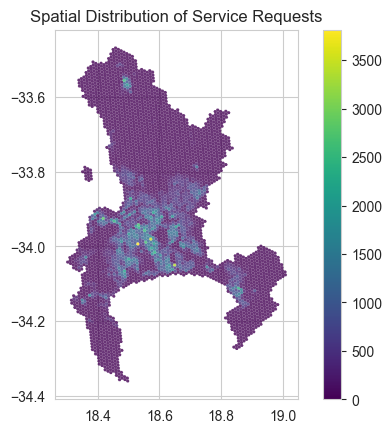

In [54]:
hex_map.plot(column="requests", cmap="viridis", legend=True, alpha=0.8, linewidth=0)
plt.title("Spatial Distribution of Service Requests")
plt.show()


Service requests show strong spatial heterogeneity across the city.

Several clear hotspots of service activity are visible, particularly in the central and southern regions of Cape Town.

This suggests that spatial context is likely to play an important role in explaining service request patterns.

In [49]:
hex_map

,index,centroid_lat,centroid_lon,geometry,h3_level8_index,requests
0,88ad361801fffff,-33.859427,18.677843,"POLYGON ((18.68119 -33.8633, 18.68357 -33.8592...",88ad361801fffff,353.0
1,88ad361803fffff,-33.855696,18.668766,"POLYGON ((18.67211 -33.85957, 18.6745 -33.8555...",88ad361803fffff,159.0
2,88ad361805fffff,-33.855263,18.685959,"POLYGON ((18.68931 -33.85914, 18.69169 -33.855...",88ad361805fffff,443.0
3,88ad361807fffff,-33.851532,18.676881,"POLYGON ((18.68023 -33.85541, 18.68261 -33.851...",88ad361807fffff,152.0
4,88ad361809fffff,-33.867322,18.678806,"POLYGON ((18.68215 -33.8712, 18.68454 -33.8671...",88ad361809fffff,407.0
...,...,...,...,...,...,...
3827,88ad369715fffff,-34.353404,18.479198,"POLYGON ((18.48255 -34.35726, 18.48494 -34.353...",NaN,0.0
3828,88ad369717fffff,-34.349672,18.470112,"POLYGON ((18.47346 -34.35353, 18.47585 -34.349...",NaN,0.0
3829,88ad369733fffff,-34.337717,18.477288,"POLYGON ((18.48063 -34.34158, 18.48303 -34.337...",NaN,0.0
3830,88ad369739fffff,-34.349293,18.487330,"POLYGON ((18.49068 -34.35315, 18.49307 -34.349...",NaN,0.0


## 4. Temporal patterns in service requests

Next we examine how the number of service requests changes over time.

Requests are aggregated by week in order to identify trends or seasonal variation.

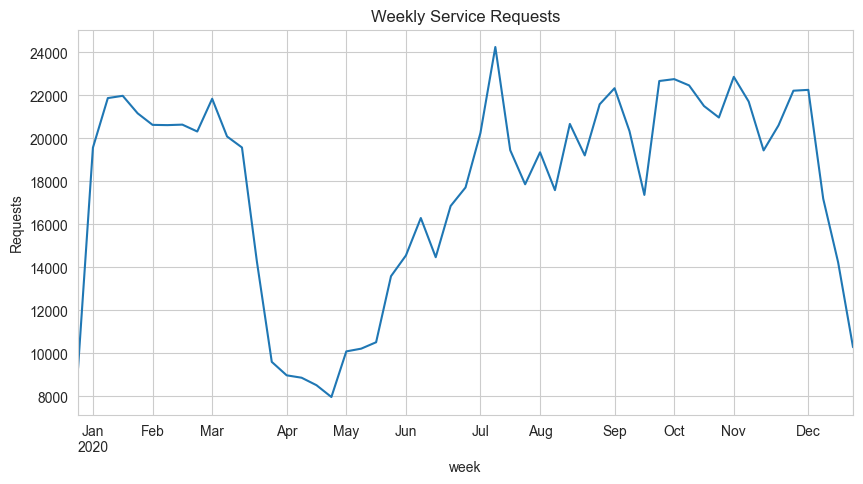

In [50]:
weekly_counts = df.groupby("week").size()

weekly_counts.plot(figsize=(10,5))
plt.title("Weekly Service Requests")
plt.ylabel("Requests")
plt.show()


The number of weekly service requests varies considerably over the year.

A noticeable drop occurs between March and May 2020, which likely corresponds to the initial COVID-19 lockdown period in South Africa. After this period, service request volumes gradually recover.

These temporal dynamics suggest that external factors can influence the number of service requests received by the municipality.

In [51]:
top_types = df["code"].value_counts().head(10).index

df_top = df[df["code"].isin(top_types)]

type_hex = (
    df_top
    .groupby(["code", "h3_level8_index"])
    .size()
    .reset_index(name="requests")
)


## 5. Spatial distribution of sewer-related requests

Given that **"Sewer: Blocked/Overflow"** is the most common request type, we examine its spatial distribution in more detail.

Requests are aggregated per H3 hexagon to identify areas where sewer-related issues occur more frequently.

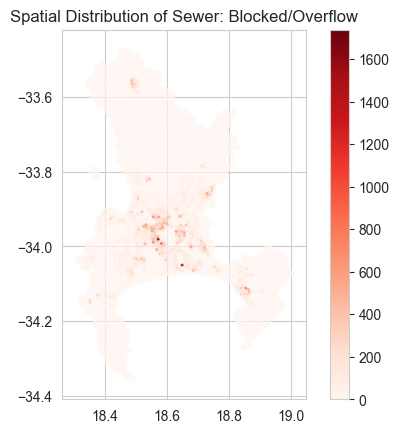

In [55]:
candidate = "Sewer: Blocked/Overflow"

subset = type_hex[type_hex["code"] == candidate]

map_df = hex_gdf.merge(
    subset,
    left_on="index",
    right_on="h3_level8_index",
    how="left"
)

map_df["requests"] = map_df["requests"].fillna(0)

map_df.plot(column="requests", cmap="Reds", legend=True, alpha=0.8, linewidth=0)
plt.title(f"Spatial Distribution of {candidate}")
plt.show()


Sewer blockage and overflow requests display clear spatial clustering.

Certain areas consistently report higher numbers of sewer-related issues, suggesting that underlying infrastructure or environmental factors may be contributing to these patterns.

In [62]:
from libpysal.weights import Queen
from esda.moran import Moran


# create spatial weights
w = Queen.from_dataframe(map_df)
w.transform = "r"

# Moran's I
moran = Moran(map_df["requests"], w)

print("Moran's I:", moran.I)
print("p-value:", moran.p_sim)


/var/folders/xc/_j3lshld5cb_rph8b7r7417r0000gn/T/ipykernel_58834/763602564.py:6: FutureWarning: `use_index` defaults to False but will default to True in future. Set True/False directly to control this behavior and silence this warning
  w = Queen.from_dataframe(map_df)


Moran's I: 0.5332086066544623
p-value: 0.001


To quantify the degree of spatial clustering in sewer-related service requests, Moran's I was calculated on the number of sewer requests per hexagon.

The resulting Moran's I statistic is **0.53** with a **p-value of 0.001**, indicating strong and statistically significant spatial autocorrelation.

This means that hexagons with high numbers of sewer-related service requests tend to be located near other hexagons with similarly high values. In other words, sewer issues are spatially clustered rather than randomly distributed across the city.

This confirms the patterns observed in the spatial maps and suggests that local infrastructure conditions or environmental factors may be driving these clusters.

## 6. Temporal pattern of sewer requests

Finally, we examine the temporal behaviour of sewer-related service requests.

Weekly aggregation allows us to observe changes in the number of sewer incidents over time.

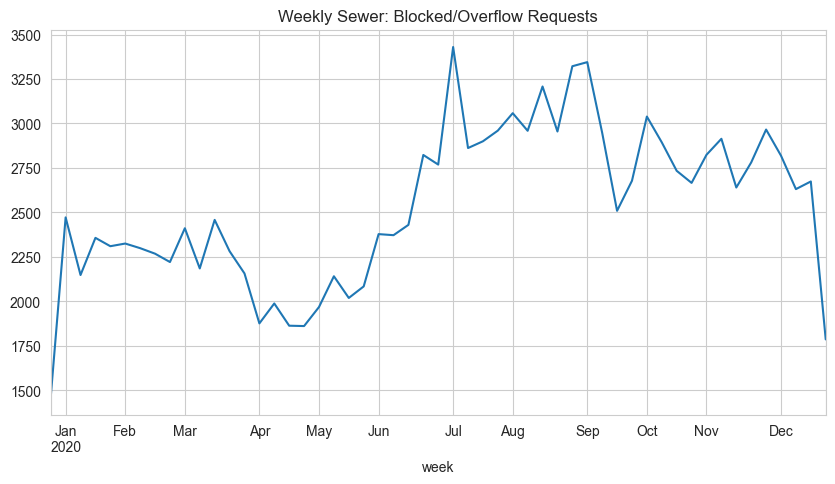

In [53]:
candidate_df = df[df["code"] == candidate]

candidate_weekly = candidate_df.groupby("week").size()

candidate_weekly.plot(figsize=(10,5))
plt.title(f"Weekly {candidate} Requests")
plt.show()


Sewer-related service requests also exhibit noticeable temporal variation.

The number of requests increases during certain periods of the year, suggesting that environmental drivers such as rainfall may influence sewer blockages and overflows.

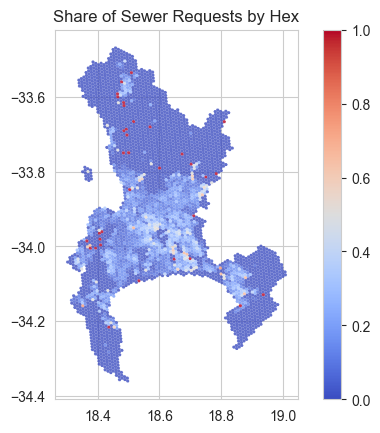

In [58]:
# total requests per hex
total_hex = df.groupby("h3_level8_index").size().reset_index(name="total_requests")

# sewer requests per hex
sewer_hex = df[df["code"] == "Sewer: Blocked/Overflow"] \
    .groupby("h3_level8_index") \
    .size() \
    .reset_index(name="sewer_requests")

# merge
ratio_df = total_hex.merge(sewer_hex, on="h3_level8_index", how="left")
ratio_df["sewer_requests"] = ratio_df["sewer_requests"].fillna(0)

ratio_df["sewer_ratio"] = ratio_df["sewer_requests"] / ratio_df["total_requests"]

# merge with polygons
map_ratio = hex_gdf.merge(
    ratio_df,
    left_on="index",
    right_on="h3_level8_index",
    how="left"
)

map_ratio["sewer_ratio"] = map_ratio["sewer_ratio"].fillna(0)

# plot
map_ratio.plot(column="sewer_ratio", cmap="coolwarm", legend=True, alpha=0.8, linewidth=0)
plt.title("Share of Sewer Requests by Hex")
plt.show()


This map shows the proportion of sewer-related service requests relative to the total number of requests in each hexagon.

By normalising sewer requests relative to overall service activity, we can identify areas where sewer problems occur disproportionately often.

These areas may indicate locations where sewer infrastructure is particularly vulnerable or where environmental conditions contribute to blockages and overflows.

## 7. Selection of modelling target

Based on the exploratory analysis above, **"Sewer: Blocked/Overflow"** was selected as the focus of the modelling exercise.

This request type was chosen for several reasons:

• It is the most frequent request category in the dataset, ensuring sufficient observations for modelling.  
• It exhibits strong spatial clustering across the city.  
• It shows meaningful temporal variation throughout the year.  
• Sewer blockages are likely influenced by environmental factors such as rainfall and infrastructure conditions.

One important feature visible in the time series is the sharp decline in total service requests between March and May 2020. This period corresponds to the first COVID-19 lockdown in South Africa, during which mobility and municipal reporting patterns changed significantly.

Because this external shock may affect the number of reported service requests, temporal effects such as lockdown periods and seasonal variation should be considered when interpreting the results of the model.

These characteristics make sewer-related requests a suitable candidate for exploring spatial and environmental drivers of service demand.